This is the screenshot of the plan and the resulting line dose in RayStation.
I created an ROI of water material in a region where there were no cell flasks I set a field to cover the entire phantom from the bottom. Energy set to 69.4 MeV with a 2 cm range shifter selected.
I took the line dose along the central axis and exported. 

![alt text](<../Line dose analysis/RayStation screenshot.png>)

In [1]:
#Preamble
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pydicom as dcm
import math
import os

In [2]:
#The data requires some preprocessing since RS adds a bunch of stuff at the beginning. Also the file is ; delimited.
#So here I read in the file and convert it to a dataframe with columns x,y,z,dose
path = r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Line dose analysis\Line dose CellFlask 29 Sep 2025_edited.xlsx"
data = pd.read_excel(path)
data = data['#X [cm];Y [cm];Z [cm];Dose [Gy (RBE)]'].str.split(';')
data = data[0:-1]

df = pd.DataFrame(columns=['X', 'Y', 'Z', 'Dose'])
for i in range(len(data)):
    row = data[i]
    row_new = np.zeros(len(row))
    for j in range(len(row)):
        row_new[j] = float(row[j])

    df.loc[len(df)] = row_new

print(df.head())

      X     Y      Z   Dose
0 -0.08 -22.5  7.657  0.421
1 -0.08 -22.5  7.658  0.443
2 -0.08 -22.5  7.659  0.465
3 -0.08 -22.5  7.660  0.488
4 -0.08 -22.5  7.661  0.510


In [3]:
#Check that line profile has single x and y values --> validate that it is perfectly straight along CAX
print(df['X'].unique())
print(df['Y'].unique())

[-0.08]
[-22.5]


(0.051, 2.033)

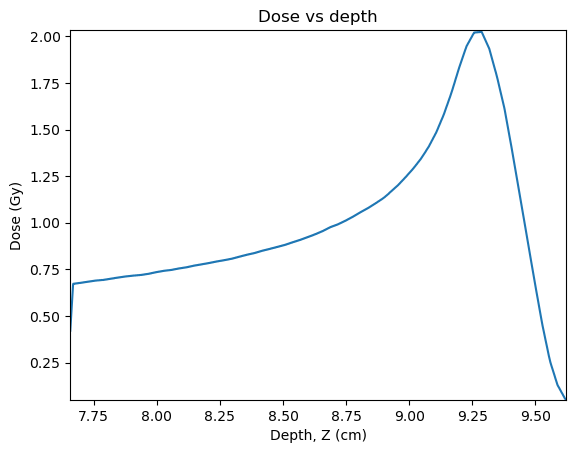

In [4]:
plt.plot(df['Z'], df['Dose'],3)
plt.title('Dose vs depth')
plt.xlabel('Depth, Z (cm)')
plt.ylabel('Dose (Gy)')
plt.xlim([min(df['Z']), max(df['Z'])])
plt.ylim([min(df['Dose']), max(df['Dose']+0.01)])

In [5]:
#Find indices of maximum dose
max_loc = np.where(df['Dose'] == max(df['Dose']))[0][-1] #The place to start calculations is the last of these
#Find index of zero
min_loc = np.where(df['Dose'] == min(df['Dose']))[0][0] #The place to finish is the first of these

#crop z and dose values 
z = np.array(df['Z'][max_loc:min_loc+1])
dose = np.array(df['Dose'][max_loc:min_loc+1])

#Find all values that occur for doses
indices = np.unique(dose, return_index=True)[1]
dose_vals = [dose[ind] for ind in sorted(indices)]

data = np.zeros([len(dose_vals),3])

for i in range(0, (len(dose_vals)-1), 1):
    #Take derivative at each point
    val_i = dose_vals[i]
    val_next = dose_vals[i+1]

    #Since many values repeat, take the derivative at the centre of each repeating section
    index = np.where(dose == val_i)[0]
    index = index[round(len(index)/2)]
    dose_i = dose[index]
    z_i = z[index]

    #Find next value
    index = np.where(dose == val_next)[0]
    index = index[round(len(index)/2)]
    dose_next = dose[index]
    z_next = z[index]


    derivative = (dose_next - dose_i)/(z_next - z_i)
    print('Derivative: ' + str(derivative) + ' Gy/mm')

    #Store data as [z, dose, derivative]
    data[i,:] = z_i, dose_i, derivative


Derivative: -3.0000000000017764 Gy/mm
Derivative: -3.0000000000017764 Gy/mm
Derivative: -3.0000000000017764 Gy/mm
Derivative: -2.999999999996003 Gy/mm
Derivative: -3.0000000000017764 Gy/mm
Derivative: -3.0000000000017764 Gy/mm
Derivative: -2.9999999999964473 Gy/mm
Derivative: -3.0000000000013323 Gy/mm
Derivative: -3.0000000000017764 Gy/mm
Derivative: -2.9999999999962252 Gy/mm
Derivative: -3.0000000000017764 Gy/mm
Derivative: -3.0000000000015543 Gy/mm
Derivative: -2.9999999999964473 Gy/mm
Derivative: -3.0000000000015543 Gy/mm
Derivative: -3.0000000000017764 Gy/mm
Derivative: -2.9999999999962252 Gy/mm
Derivative: -3.0000000000017764 Gy/mm
Derivative: -3.0000000000015543 Gy/mm
Derivative: -3.0000000000017764 Gy/mm
Derivative: -2.9999999999962252 Gy/mm
Derivative: -3.0000000000017764 Gy/mm
Derivative: -3.0000000000015543 Gy/mm
Derivative: -2.9999999999964473 Gy/mm
Derivative: -3.0000000000015543 Gy/mm
Derivative: -3.0000000000017764 Gy/mm
Derivative: -2.9999999999962252 Gy/mm
Derivative: -

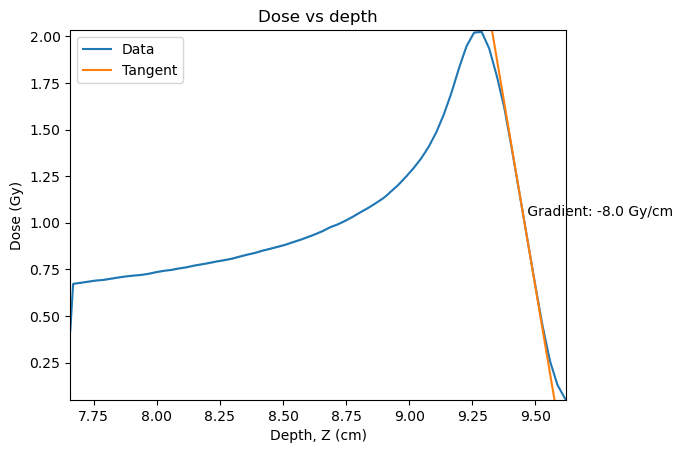

In [6]:
#Display the steepest derivative
steepest_index = np.where(data[:,2]==min(data[:,2]))[0]
if len(steepest_index) > 1:
    steepest_index = steepest_index[round(len(steepest_index)/2)]
steepest = data[steepest_index,:]

#Create tangent line
xes = np.arange((steepest[0]-0.5),(steepest[0]+0.5), 0.0001)
ys = steepest[2]*(xes-steepest[0]) + steepest[1]
text = ' Gradient: ' + str(round(steepest[2],4)) + ' Gy/cm'

#plot data
plt.plot(df['Z'], df['Dose'],label='Data')
plt.plot(xes, ys, label='Tangent')
plt.title('Dose vs depth')
plt.xlabel('Depth, Z (cm)')
plt.ylabel('Dose (Gy)')
plt.xlim([min(df['Z']), max(df['Z'])])
plt.ylim([min(df['Dose']), max(df['Dose']+0.01)])
plt.text(steepest[0], steepest[1], text)
plt.legend()

Below is the data for the thickness of the ion chamber window and the film protective layer:

![](<../Line dose analysis/Markus chamber data.png>)
![alt text](<../Line dose analysis/Film data.png>)

In [9]:
#Calculate difference between films and ion chamber
ion_window = 30 #microns, from manual found online (https://www.ptwdosimetry.com/en/products/advanced-markus-electron-chamber)
print('Ion chamber window: ' + str(ion_window) + ' microns')
film_layer = 125 #microns, from manual provided by Tord
print('Film protective layer: ' + str(film_layer) + ' microns')

diff = abs(ion_window - film_layer)
print('Difference: ' + str(diff) + ' microns')

#Recalculate derivative from Gy/cm to Gy/micron
deriv_micron = steepest[2]/10000 #derivative in Gy/micron
print('Derivative: ' + str(deriv_micron) + ' Gy/micron')

#Calculate dose difference between ion chamber and film
dose_diff = abs(deriv_micron*diff)

#Calculate relative difference with dose at ion chamber at steepest point
dose_chamber = steepest[1]
fraction_diff = (dose_chamber-dose_diff)/dose_chamber
percent_diff = (dose_diff/dose_chamber)*100
print('Film dose = ' + str(round(fraction_diff,2)) + '*ion chamber dose')
print('Film dose is ' + str(round(percent_diff,2)) + '% lower than ion chamber dose')

Ion chamber window: 30 microns
Film protective layer: 125 microns
Difference: 95 microns
Derivative: -0.0008000000000004441 Gy/micron
Film dose = 0.93*ion chamber dose
Film dose is 7.33% lower than ion chamber dose
